In [1]:
import gc
import numpy as np
import matplotlib.pyplot as plt
import torch

# === SimPEG ===
from SimPEG.config import SimpegConfig
from SimPEG.electromagnetics.static import resistivity as dc
from SimPEG.electromagnetics.static.utils.static_utils import (
    apparent_resistivity_from_voltage)
from utils.simulation_dc_resistivity import SimulationDCResistivity

def tensor_forward(model):
    gc.collect()
    # m = torch.log(model)
    surveyinfo = dict(nElec = 26, sep = 8.0, pi=0, depth= 30., typ_survey="dipole-dipole", dim="2D", data_type="volt", nlines=10, pf=208)
    SDCR = SimulationDCResistivity(model=model,surveyinfo=surveyinfo,tensor=True)
    SDCR.initialize_survey()
    SDCR.initialize_mesh(dx=1.0, dz=1, adjust_model=False, m_background=torch.mean(model))
    data = SDCR.forward_modeling(nky=12, error=0., only_data=True)
    return data

def array_forward(model):
    surveyinfo = dict(nElec = 26, sep = 8.0, pi=0, depth= 30., typ_survey="dipole-dipole", dim="2D", data_type="volt", nlines=10, pf=208)
    SDCR = SimulationDCResistivity(model=model, surveyinfo=surveyinfo)
    SDCR.initialize_survey()
    SDCR.initialize_mesh(adjust_model=False)
    results_forward = SDCR.forward_modeling(nky=12, error=0.)
    dc_data = results_forward["results"][0]
    survey = results_forward["initialize"][0]
    apparent_res = apparent_resistivity_from_voltage(survey, dc_data.dobs)

    return apparent_res, survey, SDCR


In [ ]:
cfg = SimpegConfig()
cfg.torch_is_active = True
cfg.device         = 'cpu'
cfg.dtype          = torch.float64
cfg.solver = "superlu"

# Synthetic model: background 100 ohm-m with a conductive square anomaly (10 ohm-m)
NZ, NX = 30, 208
model_np = 100.0 * np.ones((NZ, NX))
# Square anomaly centered at (x=104, z=12), size 20x10 cells
model_np[8:18, 94:114] = 10.0

m = torch.tensor(model_np.copy(), requires_grad=True, device='cpu', dtype=torch.float64)
dobs = tensor_forward(m)
loss = dobs.sum()
loss.backward()

J_aggregated_torch = m.grad.detach().numpy()


c:\Users\eaqm1\anaconda3\envs\simpeg_torch\lib\site-packages\SimPEG\electromagnetics\static\resistivity\simulation_2d.py:729: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  A = GradT @ MeSigma @ Grad + ky_tensor ** 2 * MnSigma
c:\Users\eaqm1\anaconda3\envs\simpeg_torch\lib\site-packages\SimPEG\utils\solver_utils.py:116: UserWarning: is_symmetric is not a valid keyword for splu and will be ignored
  warnings.warn(
c:\Users\eaqm1\anaconda3\envs\simpeg_torch\lib\site-packages\SimPEG\utils\solver_utils.py:116: UserWarning: is_positive_definite is not a valid keyword for splu and will be ignored
  warnings.warn(
c:\Users\eaqm1\anaconda3\envs\simpeg_torch\lib\site-packages\SimPEG\fields.py:451: UserWarning: The use o

In [3]:
cfg.torch_is_active = False
dc_vanilla = array_forward(model_np)
SDCR = dc_vanilla[2]
f= SDCR.simulation_dc.fields(SDCR.m)
J_aggregated_vanilla = SDCR.simulation_dc._Jtvec(SDCR.m,f=f).sum(axis=1)[SDCR.idx_model]



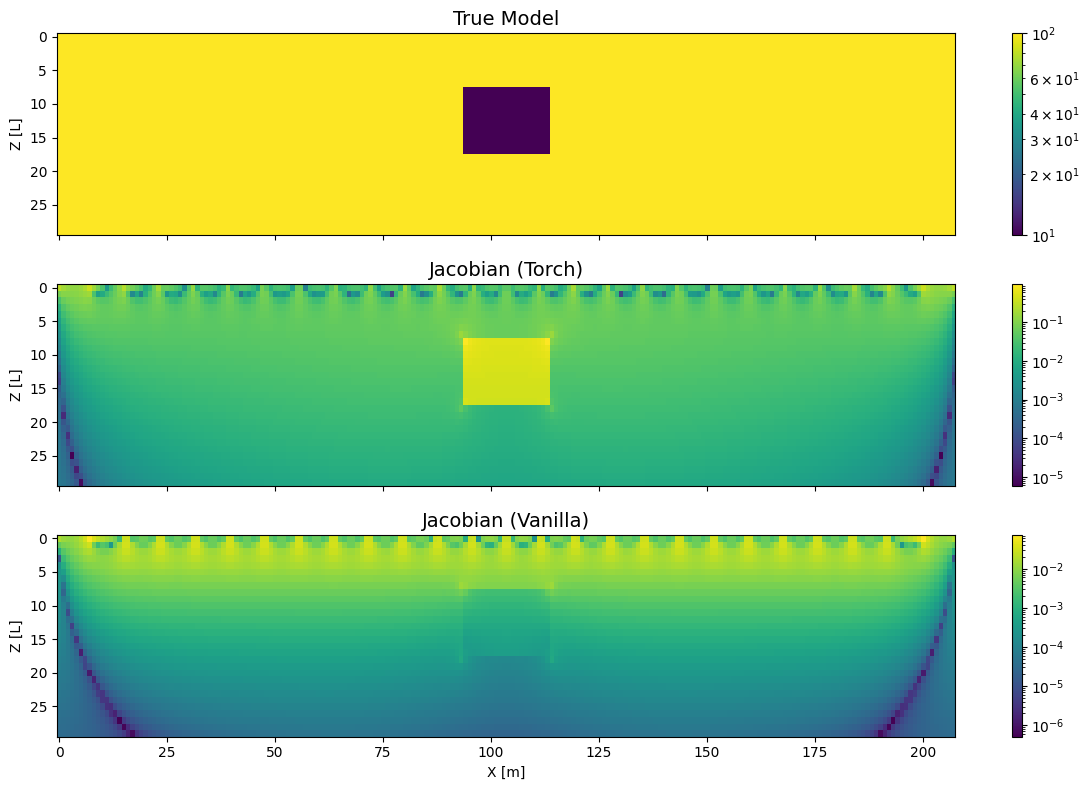

In [5]:

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# First plot: model
im0 = axes[0].imshow(model_np, norm='log', aspect='auto')
cbar0 = fig.colorbar(im0, ax=axes[0])
axes[0].set_title("True Model", fontsize=14)
axes[0].set_ylabel("Z [L]")

# Second plot: Torch Jacobian
im1 = axes[1].imshow(abs(J_aggregated_torch), norm='log', aspect='auto')
cbar1 = fig.colorbar(im1, ax=axes[1])
axes[1].set_title("Jacobian (Torch)", fontsize=14)
axes[1].set_ylabel("Z [L]")

# Third plot: Vanilla Jacobian
im2 = axes[2].imshow(abs(J_aggregated_vanilla.reshape(30,208)[::-1]), norm='log', aspect='auto')
cbar2 = fig.colorbar(im2, ax=axes[2])
axes[2].set_title("Jacobian (Vanilla)", fontsize=14)
axes[2].set_xlabel("X [m]")
axes[2].set_ylabel("Z [L]")

plt.tight_layout()
